In [1]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.odr import ODR, Model, RealData
import statsmodels.api as sm
from datetime import datetime
import statsmodels.formula.api as smf

In [2]:
root="/mnt/c/Users/soggy/OneDrive - USNH/Dox/PSIREN/ocBottleTracker/" # Change to user location
folder = root+"supportingData/"
seasoner=lambda year: {2022:"fall",2024:"spring"}[year]
fnamer=lambda site,year: "{}_{}_{}_total_Deployment_distance.csv".format(site,year,seasoner(year))
siteyears=[("anacostia",2024),("chicago",2022),("don",2022),("ipswich",2022),("miami",2024),("sfbay",2024),("socal",2024)]

In [3]:
data={}
for site,year in siteyears:
    data[site] = pd.read_csv(folder+fnamer(site,year),index_col=[0,1],dtype={"site_no":str})
data = pd.concat(data)
display(data)

dep_dt  \
                           Deployment#                              
anacostia Stingray         1            2024-01-29 15:30:00-05:00   
          Mackerel         1            2024-01-29 15:30:00-05:00   
          Moray eel        1            2024-01-29 15:30:00-05:00   
          Tern             1            2024-01-29 15:30:00-05:00   
          Leopard Seal     1            2024-01-29 15:30:00-05:00   
...                                                           ...   
socal     Fangtooth        2            2024-03-29 11:45:00-07:00   
          Orca             2            2024-03-29 11:45:00-07:00   
          Sugar kelp       2            2024-03-29 11:45:00-07:00   
          Hawksbill turtle 2            2024-03-29 11:45:00-07:00   
          Basket star      2            2024-03-29 11:45:00-07:00   

                                                              dep_geom  \
                           Deployment#                                   
anacostia Stingray         1            POINT (-77.0028781 38.9847954)   
          Mackerel         1            POINT (-77.0028781 38.9847954)   
          Moray eel        1            POINT (-77.0028781 38.9847954)   
          Tern             1            POINT (-77.0028781 38.9847954)   
          Leopard Seal     1            POINT (-77.0028781 38.9847954)   
...                                                                ...   
socal     Fangtooth        2             POINT (-117.969722 33.916944)   
          Orca             2             POINT (-117.969722 33.916944)   
          Sugar kelp       2             POINT (-117.969722 33.916944)   
          Hawksbill turtle 2             POINT (-117.969722 33.916944)   
          Basket star      2             POINT (-117.969722 33.916944)   

                                         site_no                     ret_dt  \
                           Deployment#                                        
anacostia Stingray         1            01650800  2024-04-05 10:48:00-04:00   
          Mackerel         1            01650800  2024-08-06 14:08:00-04:00   
          Moray eel        1            01650800  2024-04-05 10:25:00-04:00   
          Tern             1            01650800  2024-04-05 12:00:00-04:00   
          Leopard Seal     1            01650800  2024-04-05 12:20:00-04:00   
...                                          ...                        ...   
socal     Fangtooth        2            11088500  2024-04-08 12:49:00-07:00   
          Orca             2            11088500  2024-04-01 12:13:00-07:00   
          Sugar kelp       2            11088500  2024-04-01 12:01:00-07:00   
          Hawksbill turtle 2            11088500  2024-04-01 12:06:00-07:00   
          Basket star      2            11088500  2024-04-10 09:21:00-07:00   

                                                             ret_geom  \
                           Deployment#                                  
anacostia Stingray         1             POINT (-76.963808 38.886907)   
          Mackerel         1             POINT (-76.974816 38.956709)   
          Moray eel        1              POINT (-76.96662 38.884225)   
          Tern             1             POINT (-76.938145 38.924587)   
          Leopard Seal     1             POINT (-76.956405 38.907925)   
...                                                               ...   
socal     Fangtooth        2                    POINT (-118.1 33.735)   
          Orca             2            POINT (-118.115278 33.744167)   
          Sugar kelp       2            POINT (-118.114722 33.744722)   
          Hawksbill turtle 2               POINT (-118.115 33.744444)   
          Basket star      2              POINT (-118.10565 33.73847)   

                                            travel_m     Qmean  
                           Deployment#                          
anacostia Stingray         1            16118.845328  0.291858  
          Mackerel       

In [4]:
S=gpd.GeoSeries.from_wkt(data["dep_geom"])
gdata = gpd.GeoDataFrame(data,geometry=S,crs="EPSG:4326")
gdata

dep_dt  \
                           Deployment#                              
anacostia Stingray         1            2024-01-29 15:30:00-05:00   
          Mackerel         1            2024-01-29 15:30:00-05:00   
          Moray eel        1            2024-01-29 15:30:00-05:00   
          Tern             1            2024-01-29 15:30:00-05:00   
          Leopard Seal     1            2024-01-29 15:30:00-05:00   
...                                                           ...   
socal     Fangtooth        2            2024-03-29 11:45:00-07:00   
          Orca             2            2024-03-29 11:45:00-07:00   
          Sugar kelp       2            2024-03-29 11:45:00-07:00   
          Hawksbill turtle 2            2024-03-29 11:45:00-07:00   
          Basket star      2            2024-03-29 11:45:00-07:00   

                                                              dep_geom  \
                           Deployment#                                   
anacostia Stingray         1            POINT (-77.0028781 38.9847954)   
          Mackerel         1            POINT (-77.0028781 38.9847954)   
          Moray eel        1            POINT (-77.0028781 38.9847954)   
          Tern             1            POINT (-77.0028781 38.9847954)   
          Leopard Seal     1            POINT (-77.0028781 38.9847954)   
...                                                                ...   
socal     Fangtooth        2             POINT (-117.969722 33.916944)   
          Orca             2             POINT (-117.969722 33.916944)   
          Sugar kelp       2             POINT (-117.969722 33.916944)   
          Hawksbill turtle 2             POINT (-117.969722 33.916944)   
          Basket star      2             POINT (-117.969722 33.916944)   

                                         site_no                     ret_dt  \
                           Deployment#                                        
anacostia Stingray         1            01650800  2024-04-05 10:48:00-04:00   
          Mackerel         1            01650800  2024-08-06 14:08:00-04:00   
          Moray eel        1            01650800  2024-04-05 10:25:00-04:00   
          Tern             1            01650800  2024-04-05 12:00:00-04:00   
          Leopard Seal     1            01650800  2024-04-05 12:20:00-04:00   
...                                          ...                        ...   
socal     Fangtooth        2            11088500  2024-04-08 12:49:00-07:00   
          Orca             2            11088500  2024-04-01 12:13:00-07:00   
          Sugar kelp       2            11088500  2024-04-01 12:01:00-07:00   
          Hawksbill turtle 2            11088500  2024-04-01 12:06:00-07:00   
          Basket star      2            11088500  2024-04-10 09:21:00-07:00   

                                                             ret_geom  \
                           Deployment#                                  
anacostia Stingray         1             POINT (-76.963808 38.886907)   
          Mackerel         1             POINT (-76.974816 38.956709)   
          Moray eel        1              POINT (-76.96662 38.884225)   
          Tern             1             POINT (-76.938145 38.924587)   
          Leopard Seal     1             POINT (-76.956405 38.907925)   
...                                                               ...   
socal     Fangtooth        2                    POINT (-118.1 33.735)   
          Orca             2            POINT (-118.115278 33.744167)   
          Sugar kelp       2            POINT (-118.114722 33.744722)   
          Hawksbill turtle 2               POINT (-118.115 33.744444)   
          Basket star      2              POINT (-118.10565 33.73847)   

                                            travel_m     Qmean  \
                           Deployment#                           
anacostia Stingray         1            16118.845328  0.291858   
          Mackerel    

In [5]:
sorts = data.sort_values("travel_m").dropna(subset="travel_m")
print(sorts["travel_m"])
pd.set_option('display.precision',2)
print(sorts["travel_m"].groupby(level=0).describe().T)

                           Deployment#
ipswich  Isabel            1                 69.644908
         Innis             1                 76.703275
         Imogen            1                 76.703275
         Illario           1                 76.703275
         Icarus            1                 76.703275
                                              ...     
socal    Cuttlefish        1              29536.854693
don      Dawn              1              29582.614620
socal    Hawksbill turtle  1              35271.270183
         Basket star       1              35271.270183
         Sugar kelp        1              53495.442125
Name: travel_m, Length: 224, dtype: float64
       anacostia   chicago       don  ipswich     miami     sfbay     socal
count      38.00     41.00     38.00    26.00     12.00     33.00     36.00
mean     5620.38   3295.97   8733.76   318.71  11766.82   4676.86  14716.84
std      6099.07   4820.95   7181.92   309.01   8163.25   5682.52  11594.46
min     

In [6]:
np.unique([str(x) for x in data.site_no.values])

array(['01101500', '01102000', '01649190', '01649500', '01650500',
       '01650800', '05534500', '05535000', '05536000', '11048600',
       '11087020', '11088500', '11098000', '11102300', 'GTB', 'GV',
       'HY019', 'HY022', 'HY062', 'HY113', 'IS163', 'RMB', 'S21', 'S28',
       'S30C', 'SB', 'WCY', 'WDB'], dtype='<U8')

In [7]:
ws_position={'down':['01102000',"01649500","HY019","S30C","05536000","11087020"]+"WCY WDB".split(),
             "mid":['01101500',"01650500","HY022","S21","GV","11048600"],
             "head":["SB","IS163","01650800","01649190","HY062","HY113","S27","S22","05535000","05534500"]+"11098000 11088500 11102300".split()+"GTB GVD RMB".split()
            }
ws_names={"anacostia":"Anacostia","don":"Don","ipswich":"Ipswich","miami":"Miami","chicago":"N.Chicago","socal":"S.California","sfbay":"Walnut"}

In [8]:
data["travel_m"] / (data["ret_dt"].apply(datetime.fromisoformat) - data["dep_dt"].apply(datetime.fromisoformat)).apply(lambda x:x.days+x.seconds/86400.)

                             Deployment#
anacostia  Stingray          1               241.44
           Mackerel          1                27.41
           Moray eel         1               246.71
           Tern              1               162.91
           Leopard Seal      1               203.55
                                             ...   
socal      Fangtooth         2              2765.34
           Orca              2              8269.77
           Sugar kelp        2              8267.82
           Hawksbill turtle  2              8270.72
           Basket star       2              2276.43
Length: 262, dtype: float64

In [9]:
print("Average time of deployments across study in days for bottles that were retrieved")
(data["ret_dt"].apply(datetime.fromisoformat) - data["dep_dt"].apply(datetime.fromisoformat)).apply(lambda x:x.days+x.seconds/86400.).mean()

Average time of deployments across study in days for bottles that were retrieved


87.22551425113092

                             OLS Regression Results                             
Dep. Variable:     np.log(V_travel_m_d)   R-squared:                       0.300
Model:                              OLS   Adj. R-squared:                  0.296
Method:                   Least Squares   F-statistic:                     94.93
Date:                  Thu, 09 Apr 2026   Prob (F-statistic):           6.68e-19
Time:                          08:44:07   Log-Likelihood:                -454.52
No. Observations:                   224   AIC:                             913.0
Df Residuals:                       222   BIC:                             919.9
Df Model:                             1                                         
Covariance Type:              nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept         4.1476  

Text(0.5, 0, 'Mean discharge ($m^3 \\ s^{-1}$)')

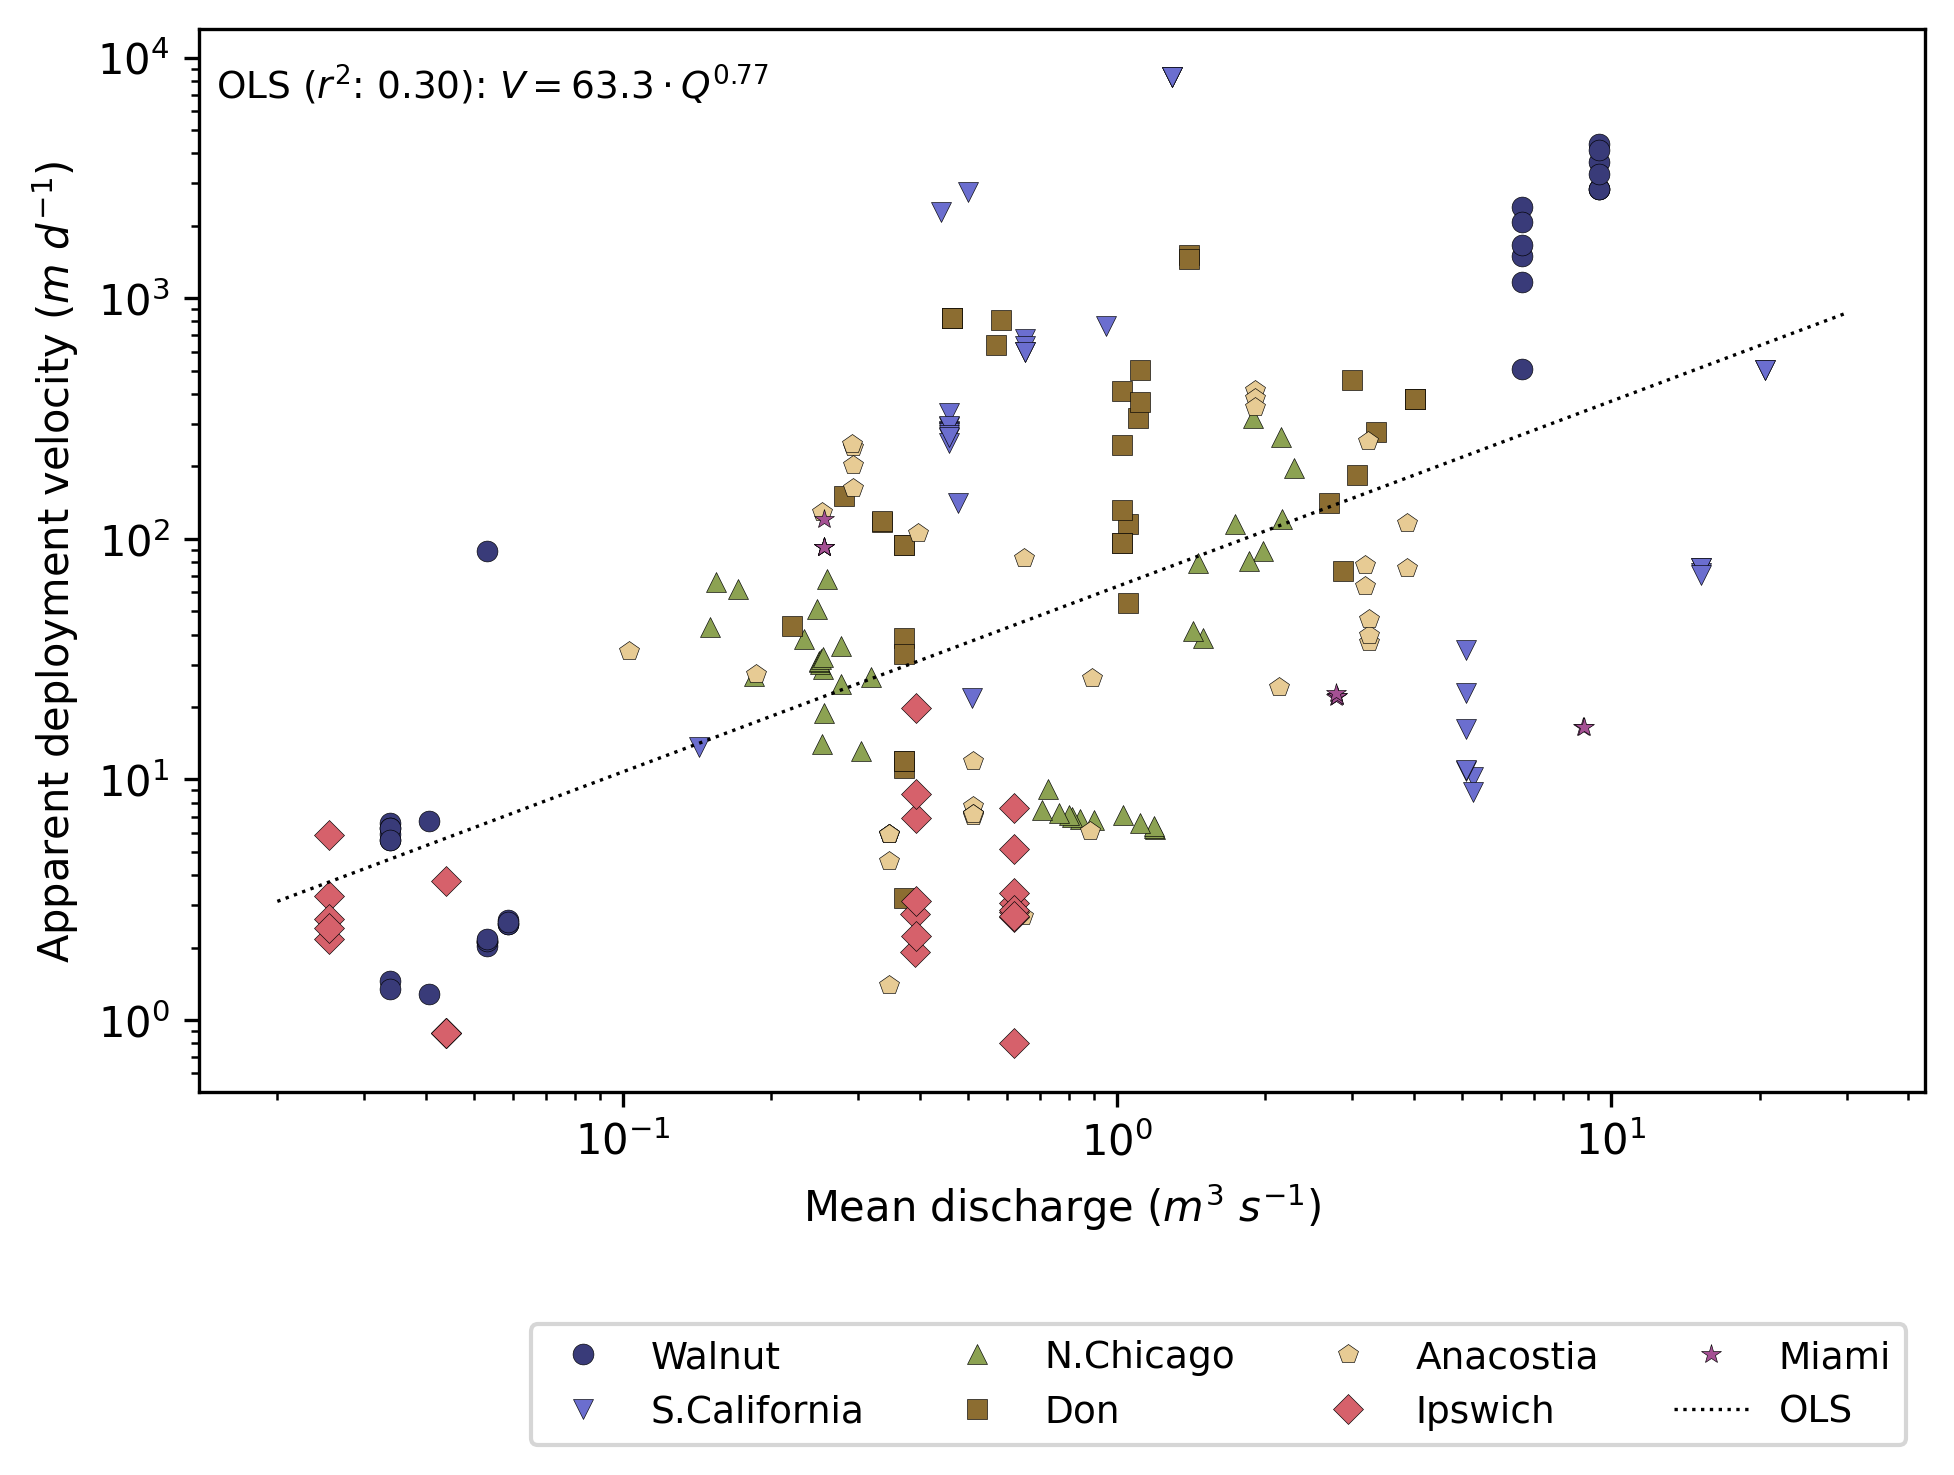

In [11]:
fig,ax=plt.subplots(1,1,dpi=300,constrained_layout=True)
nws=len(data.index.levels[0])

def get_color(uniques,cmap="tab20b"):   
    cm=mpl.colormaps[cmap]
    uniqdict=dict((unique,cm(float(j)/len(uniques))) for unique,j in zip(uniques,range(len(uniques))))
    return uniqdict

def get_marker(uniques):
    markers=["o","v","^","s","p","D","*"]
    uniqdict=dict((unique,markers[j]) for unique,j in zip(uniques,range(len(uniques))))
    return uniqdict

def get_plabel(x):
    return ws_names[x]

wseds = ['sfbay', 'socal', 'chicago','don', 'anacostia',  'ipswich', 'miami']

color_dict=get_color(wseds)
marker_dict=get_marker(wseds)

data["deploy_d"] = (data["ret_dt"].apply(datetime.fromisoformat) - data["dep_dt"].apply(datetime.fromisoformat)).apply(lambda x:x.days+x.seconds/86400.)
data["V_travel_m_d"] = data["travel_m"] / (data["ret_dt"].apply(datetime.fromisoformat) - data["dep_dt"].apply(datetime.fromisoformat)).apply(lambda x:x.days+x.seconds/86400.)

for i,ws in enumerate(wseds):
    Dat=data.xs(ws,level=0)
    
    for j,(pos,stas) in enumerate(ws_position.items()):
        heres=Dat.site_no.apply(lambda x: x in stas)

        dat = Dat.loc[heres]

    ax.plot(Dat["Qmean"],Dat["V_travel_m_d"],ls='none',markersize=5,marker=marker_dict[ws],mec='k',mew=0.15,color=color_dict[ws],label=get_plabel(ws))

ax.set_xscale('log')
ax.set_yscale('log')

mod = smf.ols("np.log(V_travel_m_d) ~ np.log(Qmean)",data=data).fit()
print(mod.summary())
beta_ols = np.flipud(mod.params)
r2_ols=mod.rsquared
Qrange = np.linspace(2e-2,3e1,5)
Vrange_ols = np.exp(beta_ols[1] + np.log(Qrange)*beta_ols[0])
ax.text(0.01,0.935,"OLS ($r^2$: {:0.2f}): $V = {:0.1f}\cdot Q ^{{{:0.2f}}}$".format(r2_ols,np.exp(beta_ols[1]),beta_ols[0]),transform=ax.transAxes,fontsize=9)
ax.plot(Qrange,Vrange_ols,'k:',lw=0.8,label="OLS")

handles,labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, loc=4,ncol=4,fontsize=9,bbox_to_anchor=[0,-0.35,1.,0.2])    
ax.set_ylabel("Apparent deployment velocity ($m \ d^{-1}$)")
ax.set_xlabel("Mean discharge ($m^3 \ s^{-1}$)")